In [39]:
from typing import TypedDict, Literal, Optional, List, Dict, Any


class ActionClassification(TypedDict):
    intent: Literal["data_add", "data_modify", "query", "report", "irrelevant"]
    summary: str
    reasoning: str

class SourceClassification(TypedDict):
    source: Literal["outage_reports", "demand_reports", "both"]
    reasoning: str

class AgentActionState(TypedDict):
    user_request: str
    classification: Optional[ActionClassification]
    source_classification: Optional[SourceClassification]

    # Data retrieved by Data Agent
    issue_search_results: Optional[List[str]] # Unstructured data from ChromaDB
    demand_search_results: Optional[Dict[str, Any]] # Structured data from Pandas

    # Agent Communication
    messages: List[str]
    drafted_response: Optional[str]

In [40]:
import pandas as pd
import sqlite3

def setup_database(csv_path: str, db_path: str = "energy_data.db"):
    """Reads a CSV, cleans it, and stores it in SQLite."""
    # 1. Load the data
    df = pd.read_csv(csv_path)

    # 2. Basic Cleaning (Example: drop empty rows, ensure dates are datetime)
    df.dropna(inplace=True)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    # 3. Connect to SQLite and write the data
    conn = sqlite3.connect(db_path)
    # writes the dataframe to a table named 'demand_reports'
    df.to_sql('demand_reports', conn, if_exists='replace', index=False)

    print(f"Successfully loaded {len(df)} records into SQLite database.")

    # Retrieve the schema to feed to the LLM later
    schema = pd.io.sql.get_schema(df, 'demand_reports')
    conn.close()

    return schema

# Setup LLMs

In [41]:
from langchain_ollama import ChatOllama

reasoning_llm = ChatOllama(
    model="deepseek-r1:7b",
    reasoning=True,
    temperature=0.5,
    num_ctx=8192
)

coder_llm = ChatOllama(
    model="codeqwen:latest",
    temperature=0.0,
    num_ctx=2048
)

In [42]:
from langgraph.types import Command

def classify_intent(state: AgentActionState) -> Command[Literal["classify_sources", "draft_response"]]:
    """Use LLM to classify the user's intent and route accordingly."""
    # FIXED: Was previously using SourceClassification
    structured_text_llm = reasoning_llm.with_structured_output(ActionClassification)

    classification_prompt = f"""
    You are an expert energy supply analysis and report generation agent.
    Analyze the user's message and classify its intent.
    Any request not related to power grids, energy demand, or outages should be 'irrelevant'.

    User's request: {state['user_request']}
    """

    classification: ActionClassification = structured_text_llm.invoke(classification_prompt)

    goto = "draft_response" if classification["intent"] == "irrelevant" else "classify_sources"

    return Command(
        goto=goto,
        update={"classification": classification},
    )


In [43]:
def classify_sources(state: AgentActionState) -> Command[Literal["data_agent", "report_agent", "analysis_agent"]]:
    """Determine which data sources are needed."""
    # FIXED: Was previously using ActionClassification
    structured_text_llm = reasoning_llm.with_structured_output(SourceClassification)

    classifications_prompt = f"""
    Which sources contain the answer to the user's query?
    - "outage_reports": Unstructured text about grid outages/faults.
    - "demand_reports": Structured logs of consumption/generation.
    - "both": If both are needed.

    User's query: {state['user_request']}
    Intent Summary: {state["classification"].get("summary", "Unknown")}
    """

    classification: SourceClassification = structured_text_llm.invoke(classifications_prompt)

    # Route based on the determined intent from the first step
    intent = state["classification"]["intent"]
    if intent in ["data_add", "data_modify"]:
        goto = "data_agent"
    elif intent == "query":
        goto = "analysis_agent"
    else:
        goto = "report_agent"

    return Command(
        goto=goto,
        update={"source_classification": classification},
    )



In [44]:
import sqlite3
import pandas as pd
import re
from langchain_core.prompts import PromptTemplate

def get_dynamic_schema(db_path: str = "energy_data.db") -> str:
    """Extracts the exact, current schema from the SQLite database."""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        # Fetch the CREATE TABLE statements for all tables
        cursor.execute("SELECT sql FROM sqlite_master WHERE type='table';")
        schemas = [row[0] for row in cursor.fetchall() if row[0] is not None]
        conn.close()

        if not schemas:
            return "No tables exist in the database yet."
        return "\n\n".join(schemas)
    except Exception as e:
        return f"Error reading schema: {e}"

In [45]:
def data_agent(state: AgentActionState) -> Command[Literal["analysis_agent", "report_agent"]]:
    """Handles dynamic imports, queries, and modifications."""
    intent = state["classification"]["intent"]
    user_request = state["user_request"]
    updates = {}

    db_path = "energy_data.db"
    if intent == "data_add":
        match = re.search(r'[\w\-]+\.csv', user_request)
        if match:
            csv_file = match.group(0)
            try:
                # Pandas automatically determines columns, data types, and order
                df = pd.read_csv(csv_file)

                conn = sqlite3.connect(db_path)
                # 'replace' overwrites the table, 'append' adds to it.
                # We use a generic table name here, but you could ask the LLM to name it.
                df.to_sql("demand_reports", conn, if_exists="replace", index=False)
                conn.close()

                updates["messages"] = state.get("messages", []) + [
                    f"Data Agent: Successfully imported {len(df)} rows from {csv_file}. The database schema has been updated."
                ]
            except Exception as e:
                updates["messages"] = state.get("messages", []) + [f"Data Agent Error: Could not load {csv_file}. {e}"]
        else:
             updates["messages"] = state.get("messages", []) + ["Data Agent: Please provide a valid .csv filename to import."]

        # Skip analysis and go straight to reporting the success/failure
        return Command(goto="report_agent", update=updates)

    # ---------------------------------------------------------
    # ACTION: QUERY OR MODIFY DATA (Interactive SQL Generation)
    # ---------------------------------------------------------
    elif intent in ["query", "data_modify"]:
        current_schema = get_dynamic_schema(db_path)

        # We adjust the prompt based on whether they are asking a question or changing data
        action_type = "read-only SELECT query" if intent == "query" else "Data Manipulation Language (UPDATE, DELETE, INSERT) query"

        sql_prompt = PromptTemplate.from_template("""
        You are an expert SQLite developer. Write a {action_type} to fulfill the user's request.
        Only return the raw SQL query. Do not wrap it in markdown formatting like ```sql.

        Current Database Schema:
        {schema}

        User Request: {question}

        SQL Query:
        """)

        chain = sql_prompt | coder_llm
        sql_query = chain.invoke({
            "action_type": action_type,
            "schema": current_schema,
            "question": user_request
        }).content.strip()

        print(f"\n[Data Agent] Generated SQL: {sql_query}\n")

        try:
            conn = sqlite3.connect(db_path)

            if intent == "query":
                # For SELECT queries, return the data
                results_df = pd.read_sql_query(sql_query, conn)
                updates["demand_search_results"] = results_df.to_dict(orient='records')
                next_node = "analysis_agent"
            else:
                # For UPDATE/DELETE, execute and commit, then return rows affected
                cursor = conn.cursor()
                cursor.execute(sql_query)
                conn.commit()
                updates["messages"] = state.get("messages", []) + [
                    f"Data Agent: Database updated successfully. {cursor.rowcount} row(s) affected."
                ]
                # Skip analysis for modifications, go straight to report
                next_node = "report_agent"

            conn.close()

        except Exception as e:
            error_msg = f"SQL Execution Failed: {str(e)}\nAttempted Query: {sql_query}"
            updates["messages"] = state.get("messages", []) + [f"Data Agent: {error_msg}"]
            next_node = "report_agent"

        return Command(goto=next_node, update=updates)

    # Fallback
    return Command(goto="report_agent", update=updates)

In [46]:
def analysis_agent(state: AgentActionState) -> Command[Literal["report_agent"]]:
    """Analyzes the retrieved data to extract exact answers."""
    analysis_prompt = f"""
    Analyze the following energy data to answer the user's query.
    User Query: {state['user_request']}

    Outage Data (Unstructured): {state.get('issue_search_results', 'None')}
    Demand Data (Structured): {state.get('demand_search_results', 'None')}
    """

    # Using standard LLM for analysis
    response = reasoning_llm.invoke(analysis_prompt)

    # Append the analysis to the messages
    messages = state.get("messages", [])
    messages.append(f"Analysis Agent: {response.content}")

    return Command(goto="report_agent", update={"messages": messages})

In [47]:
def report_agent(state: AgentActionState) -> Command[Literal["draft_response"]]:
    """Formats the final decision support response in natural language."""
    report_prompt = f"""
    Draft a concise, professional response based on this analysis:
    {state.get('messages', ['No analysis available.'])}
    """

    response = reasoning_llm.invoke(report_prompt)

    return Command(goto="draft_response", update={"drafted_response": response.content})

In [48]:
def draft_response(state: AgentActionState):
    """Final node to output the drafted response or handle irrelevant queries."""
    if state.get("classification", {}).get("intent") == "irrelevant":
        return {"drafted_response": "I am an energy management assistant. I can only assist with power supply, demand, and outage queries."}

    return {"drafted_response": state["drafted_response"]}

In [49]:
from langgraph.constants import START, END
from langgraph.graph import StateGraph

builder = StateGraph(AgentActionState)

# Add all nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("classify_sources", classify_sources)
builder.add_node("data_agent", data_agent)
builder.add_node("analysis_agent", analysis_agent)
builder.add_node("report_agent", report_agent)
builder.add_node("draft_response", draft_response)

# The workflow starts at intent classification
builder.add_edge(START, "classify_intent")
builder.add_edge("draft_response", END)

# Compile the graph
app = builder.compile()

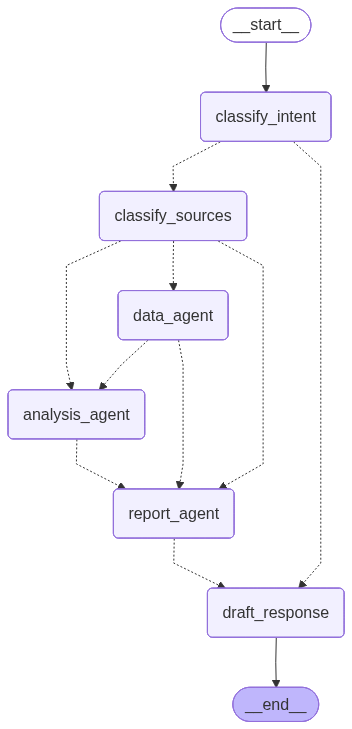

In [50]:
from IPython.core.display import Image
Image(app.get_graph().draw_mermaid_png())

In [54]:
import os

def run_energy_assistant_cli(agent_app):
    """Runs a command-line chat interface for the LangGraph agent."""

    print("="*60)
    print(" ⚡ Agent-Based Energy Management Assistant (CLI Mode) ⚡")
    print("="*60)
    print("Instructions:")
    print("- Type your question and press Enter.")
    print("- To import data, ensure the CSV is uploaded to your Colab files pane,")
    print("  then type: import <filename.csv>")
    print("- Type 'exit' or 'quit' to end the session.")
    print("="*60)

    while True:
        # Get user input
        user_input = input("\nYou: ").strip()

        # Check for exit commands
        if user_input.lower() in ['exit', 'quit']:
            print("\nAssistant: Shutting down. Goodbye!")
            break

        # Skip empty inputs
        if not user_input:
            continue

        # Handle the special "import" macro for easy Colab testing
        if user_input.lower().startswith("import "):
            filename = user_input.split(" ", 1)[1].strip()
            if not os.path.exists(filename):
                print(f"\n[System Error]: Could not find '{filename}'. Did you upload it to the Colab file browser?")
                continue

            print(f"\n[System]: Instructing Data Agent to process '{filename}'...")
            prompt = f"Import the data from {filename}"
        else:
            prompt = user_input

        print("Assistant is thinking...\n")

        try:
            # Prepare state and invoke the graph
            initial_state = {
                "user_request": prompt,
                "messages": []
            }

            result = agent_app.invoke(initial_state)

            # Print the final drafted response
            response = result.get("drafted_response", "Error: No response generated.")
            print(f"Assistant: {response}")

            # Print internal agent logs to verify orchestration is working
            if result.get("messages"):
                print("\n--- Agent Execution Logs ---")
                for log in result["messages"]:
                    print(f">> {log}")
                print("----------------------------")

        except Exception as e:
            print(f"\n[Execution Error]: {e}")


In [55]:
run_energy_assistant_cli(app)

 ⚡ Agent-Based Energy Management Assistant (CLI Mode) ⚡
Instructions:
- Type your question and press Enter.
- To import data, ensure the CSV is uploaded to your Colab files pane,
  then type: import <filename.csv>
- Type 'exit' or 'quit' to end the session.
Assistant is thinking...


[Execution Error]: [Errno 111] Connection refused


KeyboardInterrupt: Interrupted by user